# **Boston University Neurophotonics Center Summer School**
## Fluorescence and Intrinsic Widefield Imaging In Vivo

Code used to process and analyze widefield Ca2+, neuromodulation, and hemodynamics data. Includes hemodynamic correction algorithms, allen atlas parcellation, functional connectivity analysis, and impulse response function (IRF) modeling.

*author: Brad Rauscher (June, 2026)*

### **Mount google drive and load data** ###

data - shape (channel x time x H x W)

masks - shape (mask x H x W)

In [1]:
from google.colab import drive
import numpy as np
drive.mount('/content/drive')

data = np.load('/content/drive/MyDrive/SummerSchool2026/data.npy').transpose((3,2,0,1))
masks = np.load('/content/drive/MyDrive/SummerSchool2026/masks.npy').transpose((2,0,1))

Mounted at /content/drive


### **Display overview images** ###

Channel 1 - 470 nm, gfp, GRAB_NE fluorescence

Channel 2 - 565 nm, rfp, Ca2+, Thy1_jRGECO1a fluorescence

Channel 3 - 525 nm, reflectance ch 1

Channel 4 - 625 nm, reflectance ch 2

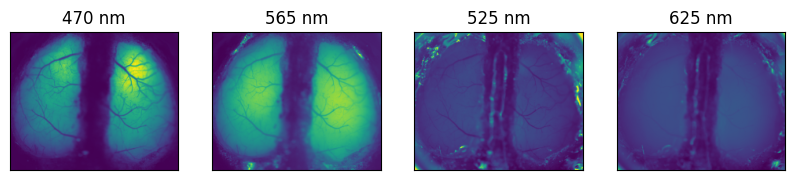

In [2]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(10,5))

for i in range(4):
    axes[i].imshow(data[i].mean(axis=0))

[axes[i].set_yticks([]) for i in range(4)]
[axes[i].set_xticks([]) for i in range(4)]
[axes[i].set_title(n) for i,n in enumerate(['470 nm','565 nm','525 nm','625 nm'])]
plt.show()

### **Calculate ∆F/F for gfp and rfp** ###

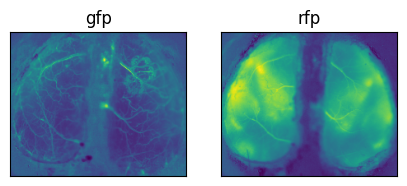

In [3]:
def compute_dff(data):
    return data / data.mean(axis=0, keepdims=True) - 1

gfp = 100 * compute_dff(data[0]) # calculate dF/F in %
rfp = 100 * compute_dff(data[1]) # calculate dF/F in %

fig, axes = plt.subplots(1, 2, figsize=(5,5))

axes[0].imshow(gfp.std(axis=0))
axes[1].imshow(rfp.std(axis=0))

[axes[i].set_yticks([]) for i in range(2)]
[axes[i].set_xticks([]) for i in range(2)]
[axes[i].set_title(n) for i,n in enumerate(['gfp','rfp'])]
plt.show()

### **Estimate hemodynamics** ###

HbO - oxygenated hemoglobin

HbR - non-oxygenated hemoglobin

HbT - total hemoglobin

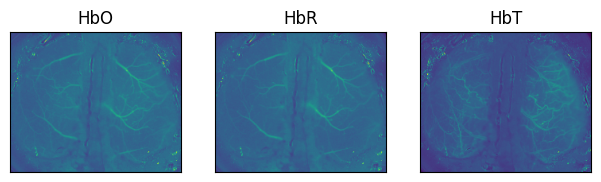

In [4]:
from scipy.interpolate import interp1d
import pandas as pd

def getExtinctionCoefficients(Lambda):
    """Returns the extinction coefficients for
    [HbO,Hb]."""

    num_lambda = len(Lambda)
    
    vLambdaHbOHb = pd.read_csv('/content/drive/MyDrive/SummerSchool2026/Hb_Lambda_Coefficients.csv', header=None)

    vLambdaHbOHb[1] = vLambdaHbOHb[1] * 2.303
    vLambdaHbOHb[2] = vLambdaHbOHb[2] * 2.303

    exs = np.zeros((num_lambda, 2))

    f1 = interp1d(vLambdaHbOHb[:][0], vLambdaHbOHb[:][1], bounds_error=False, fill_value="extrapolate")
    f2 = interp1d(vLambdaHbOHb[:][0], vLambdaHbOHb[:][2], bounds_error=False, fill_value="extrapolate")
    
    exs[:,0] = f1(Lambda)
    exs[:,1] = f2(Lambda)

    return exs

def estimatePathlengths(Lambda, factor=0.4):
    """Returns estimated path lengths for Lambda"""
    HbO = 60e-6
    Hb = 40e-6
    g = 0.9
    c = 3e10
    e = getExtinctionCoefficients(Lambda)

    mua = e[:,0] * HbO + e[:,1] * Hb
    mus = factor * 150 * (Lambda / 560) ** (-2)

    z0 = 1 / ((1 - g) * mus)
    gamma = np.sqrt(c / (3 * (mua + (1 - g) * mus)))

    pathlengths = (c * z0 / (2 * gamma * np.sqrt(mua * c))) * (1 + (3 / c) * mua * gamma ** 2)

    return pathlengths

def estimateHemodynamics(ch1, ch2, lambda1=525, lambda2=625):
    """Returns estimated fluctuations in HbO and Hb concentration"""
    exs = getExtinctionCoefficients(np.array([lambda1, lambda2]))
    PLs = estimatePathlengths(np.array([lambda1, lambda2]))

    exsLambda1Hb = exs[0,1]
    exsLambda1HbO = exs[0,0]
    exsLambda2Hb = exs[1,1]
    exsLambda2HbO = exs[1,0]

    pathLambda1 = PLs[0]
    pathLambda2 = PLs[1]

    cLambda1HbO = 1 / pathLambda1 * (exsLambda2Hb / (exsLambda2HbO * exsLambda1Hb - exsLambda1HbO * exsLambda2Hb))
    cLambda2HbO = 1 / pathLambda2 * (exsLambda1Hb / (exsLambda2HbO * exsLambda1Hb - exsLambda1HbO * exsLambda2Hb))
    cLambda1Hb = 1 / pathLambda1 * (exsLambda2HbO / (exsLambda2Hb * exsLambda1HbO - exsLambda2HbO * exsLambda1Hb))
    cLambda2Hb = 1 / pathLambda2 * (exsLambda1HbO / (exsLambda2Hb * exsLambda1HbO - exsLambda2HbO * exsLambda1Hb))

    A0Hb = cLambda2Hb * np.log(np.mean(ch2, axis=0)) - cLambda1Hb * np.log(np.mean(ch1, axis=0))
    A0HbO = cLambda2HbO * np.log(np.mean(ch2, axis=0)) - cLambda1HbO * np.log(np.mean(ch1, axis=0))

    HbO = A0HbO + cLambda1HbO * np.log(ch1) - cLambda2HbO * np.log(ch2)
    HbR = A0Hb + cLambda1Hb * np.log(ch1) - cLambda2Hb * np.log(ch2)

    return HbO, HbR

HbO, HbR = estimateHemodynamics(data[2], data[3])
HbO = 1e6 * HbO
HbR = 1e6 * HbR

HbT = HbO + HbR

fig, axes = plt.subplots(1, 3, figsize=(7.5,5))

axes[0].imshow(HbO.std(axis=0))
axes[1].imshow(HbR.std(axis=0))
axes[2].imshow(HbT.std(axis=0))

[axes[i].set_yticks([]) for i in range(3)]
[axes[i].set_xticks([]) for i in range(3)]
[axes[i].set_title(n) for i,n in enumerate(['HbO','HbR','HbT'])]
plt.show()

### **Green hemodynamic correction** ###

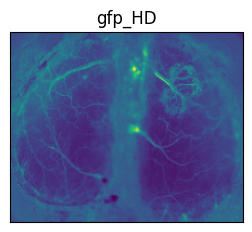

In [5]:
def green_HD_correction(gfp, HbO, HbR, WL=np.array([470, 515])):
    """Apply a correction to the green channel signal to 
    account for HD artifact."""
    
    exs = getExtinctionCoefficients(WL)
    pathEx = estimatePathlengths(np.array([WL[0]])) / 2
    pathEm = estimatePathlengths(np.array([WL[1]])) / 2

    muaEx = (exs[0, 0] * HbO) + (exs[0, 1] * HbR)
    muaEm = (exs[1, 0] * HbO) + (exs[1, 1] * HbR)

    gfp_HD = (gfp + 1) / np.exp(-(muaEx * pathEx + muaEm * pathEm)) - 1

    return gfp_HD

gfp_HD = 100 * green_HD_correction(gfp / 100, HbO / 1e6, HbR / 1e6)

fig, axes = plt.subplots(1, 1, figsize=(3,5))

axes.imshow(gfp_HD.std(axis=0))

axes.set_yticks([])
axes.set_xticks([])
axes.set_title('gfp_HD')
plt.show()

### **Red hemodynamic correction** ###

(1) Excitation path $$ I_{ex}(t,\lambda_ex) = I_{0,ex}(t,\lambda_{ex})e^{-\mu_a(t,\lambda_{ex})X_{ex}(\lambda_{ex})} $$

(2) Excitation to emission $$ I_{0,em}(t,\lambda_{em}) = c_FF(t)I_{ex}(t,\lambda_{ex}) $$

(3) Emission path $$ I_{em}(t,\lambda_{em}) = I_{0,em}(t,\lambda_{em})e^{-\mu_a(t,\lambda_{em})X_{em}(\lambda_{em})} $$

(4) Combine 1-3 $$ I_{em}(t,\lambda_{em}) = c_FF(t)I_{0,ex}(t,\lambda_{ex})e^{-\mu_a(t,\lambda_{em})X_{em}(\lambda_{em})}e^{-\mu_a(t,\lambda_{ex})X_{ex}(\lambda_{ex})} $$

(5) Divide by baseline $$  $$

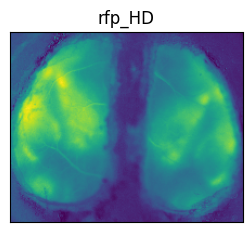

In [6]:
def red_HD_correction(rfp, ch1, ch2, baseline=None):
    """Apply a correction to the red channel signal to 
    account for HD artifact."""
    
    HbRed = compute_dff(ch2) + 1
    HbGreen = compute_dff(ch1) + 1

    rfp_HD = (rfp + 1) / (HbRed**0.8 * HbGreen**0.4) - 1

    return rfp_HD

rfp_HD = 100 * red_HD_correction(rfp / 100, data[2], data[3])

fig, axes = plt.subplots(1, 1, figsize=(3,5))

axes.imshow(rfp_HD.std(axis=0))

axes.set_yticks([])
axes.set_xticks([])
axes.set_title('rfp_HD')
plt.show()

### **Allen atlas parcellation** ###

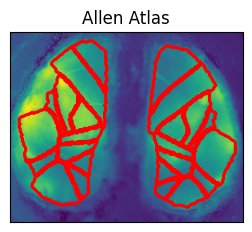

In [7]:
from skimage.segmentation import find_boundaries

fig, axes = plt.subplots(1, 1, figsize=(3,5))

axes.imshow(rfp_HD.std(axis=0))

for i in range(12):
    outline = find_boundaries(masks[i].astype(bool), mode="outer")
    axes.contour(outline, levels=[0.5], colors='r')

axes.set_yticks([])
axes.set_xticks([])
axes.set_title('Allen Atlas')
plt.show()

### **Plot ROIs** ###

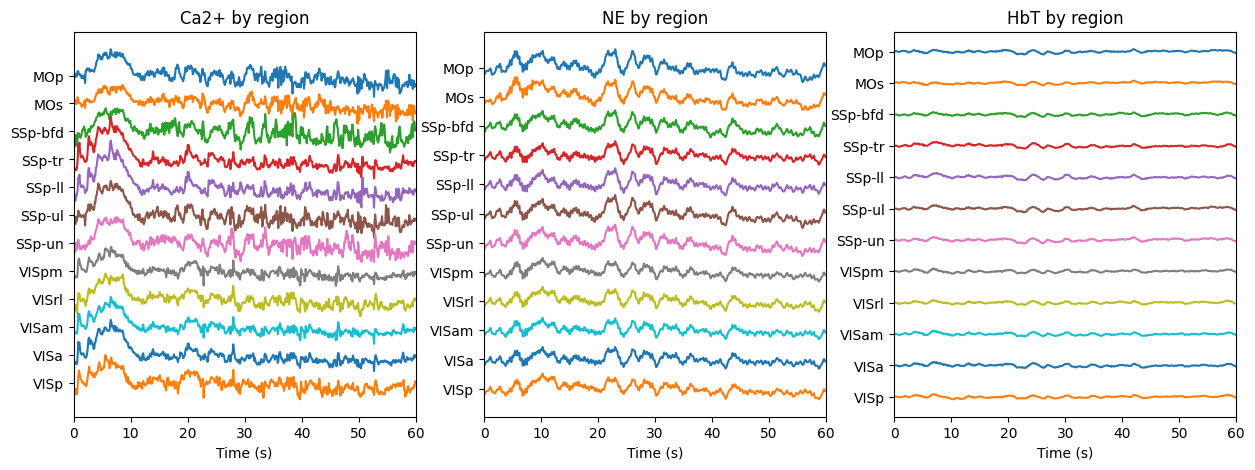

In [8]:
T = rfp_HD.shape[0]

rois_rfp_HD = np.zeros((T, 12))
rois_rfp = np.zeros((T, 12))
rois_gfp_HD = np.zeros((T, 12))
rois_gfp = np.zeros((T, 12))
rois_HbT = np.zeros((T, 12))

for i in range(12):
    rois_rfp_HD[:,i] = rfp_HD[:,masks[i].astype(bool)].mean(axis=1)
    rois_rfp[:,i] = rfp[:,masks[i].astype(bool)].mean(axis=1)
    rois_gfp_HD[:,i] = gfp_HD[:,masks[i].astype(bool)].mean(axis=1)
    rois_gfp[:,i] = gfp[:,masks[i].astype(bool)].mean(axis=1)
    rois_HbT[:,i] = HbT[:,masks[i].astype(bool)].mean(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15,5))
for i in range(12):
    axes[0].plot(np.arange(0,T/10,0.1), rois_rfp_HD[:,i] - i * 8)
    axes[1].plot(np.arange(0,T/10,0.1), rois_gfp_HD[:,i] - i * 8)
    axes[2].plot(np.arange(0,T/10,0.1), rois_HbT[:,i] - i * 8)

for i in range(3):
    axes[i].set_yticks(np.arange(0,-89,-8))
    axes[i].set_yticklabels(['MOp','MOs','SSp-bfd','SSp-tr','SSp-ll','SSp-ul','SSp-un','VISpm','VISrl','VISam','VISa','VISp'])
    axes[i].set_xlabel('Time (s)')
    axes[i].set_xlim(0,60)
axes[0].set_title('Ca2+ by region')
axes[1].set_title('NE by region')
axes[2].set_title('HbT by region')
plt.show()

### **Plot hemodynamic corrected data** ###

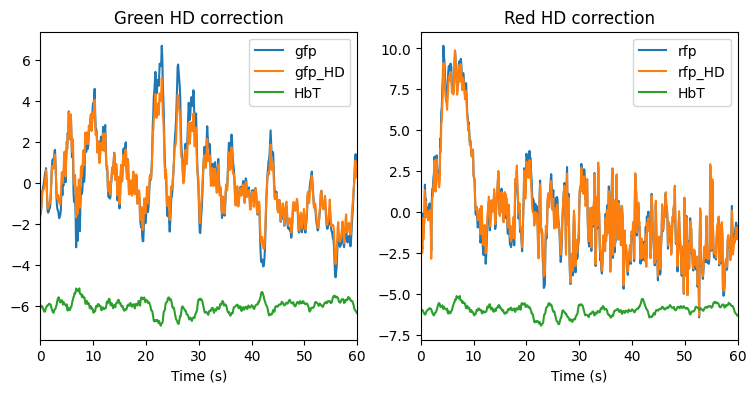

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9,4))

axes[0].plot(np.arange(0,T/10,0.1), rois_gfp[:,5])
axes[0].plot(np.arange(0,T/10,0.1), rois_gfp_HD[:,5])
axes[0].plot(np.arange(0,T/10,0.1), rois_HbT[:,5] - 6)

axes[1].plot(np.arange(0,T/10,0.1), rois_rfp[:,5])
axes[1].plot(np.arange(0,T/10,0.1), rois_rfp_HD[:,5])
axes[1].plot(np.arange(0,T/10,0.1), rois_HbT[:,5] - 6)

axes[0].legend(['gfp','gfp_HD','HbT'])
axes[0].set_title('Green HD correction')
axes[1].legend(['rfp','rfp_HD','HbT'])
axes[1].set_title('Red HD correction')
[axes[i].set_xlabel('Time (s)') for i in range(2)]
[axes[i].set_xlim(0,60) for i in range(2)]

plt.show()

### **Functional connectivity analysis** ###

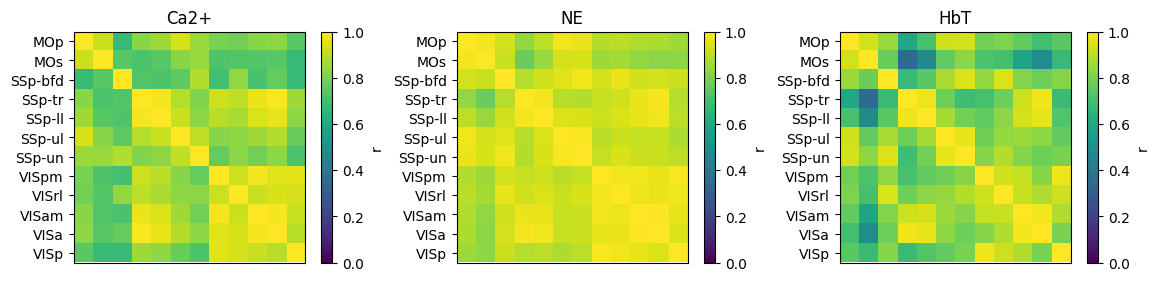

In [10]:
FC_Ca = np.corrcoef(rois_rfp_HD, rowvar=False)
FC_NE = np.corrcoef(rois_gfp_HD, rowvar=False)
FC_HbT = np.corrcoef(rois_HbT, rowvar=False)

fig, axes = plt.subplots(1, 3, figsize=(14,3))

im = []
im.append(axes[0].imshow(FC_Ca))
im.append(axes[1].imshow(FC_NE))
im.append(axes[2].imshow(FC_HbT))

[axes[i].set_yticks(np.arange(0,12,1)) for i in range(3)]
[axes[i].set_yticklabels(['MOp','MOs','SSp-bfd','SSp-tr','SSp-ll','SSp-ul','SSp-un','VISpm','VISrl','VISam','VISa','VISp']) for i in range(3)]
[axes[i].set_xticks([]) for i in range(3)]
[im[i].set_clim(0,1) for i in range(3)]
[axes[i].set_title(n) for i,n in enumerate(['Ca2+','NE','HbT'])]
for i in range(3):
    c = plt.colorbar(im[i], ax=axes[i])
    c.set_label('r')
plt.show()

### **Impulse response function modeling** ###


Solve the following for IRF:

$$

IRF * Ca(t) = HbT(t)

$$

Use toeplitz convolution for efficiency:

$$

\begin{bmatrix}

Ca_0 & 0 & 0 & ... & 0\\

Ca_1 & Ca_0 & 0 & ... & 0\\

Ca_2 & Ca_1 & Ca_0 & ... & 0\\

... & ... & ... & ... & ...\\

Ca_T & Ca_{T-1} & Ca_{T-2} & ... & Ca_{T-100}

\end{bmatrix}

*

\begin{bmatrix}

IRF_0\\

IRF_1\\

IRF_2\\

...\\

IRF_100

\end{bmatrix}

=

\begin{bmatrix}

HbT_0\\

HbT_1\\

HbT_2\\

...\\

HbT_T

\end{bmatrix}

$$

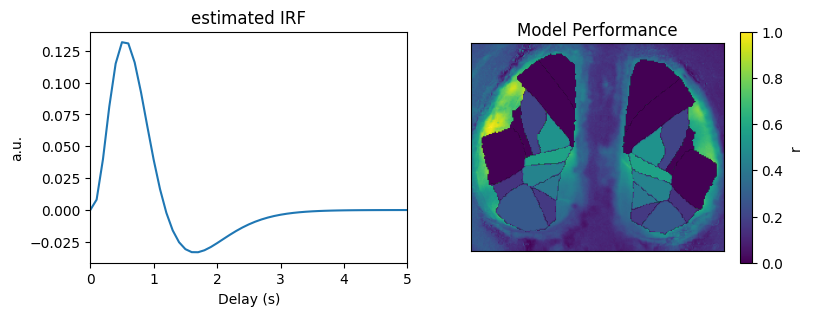

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view
from scipy.signal import convolve2d
from scipy.optimize import least_squares

def alpha_IRF(t0, tau1, tau2, A, B, range):
    # calculates double alpha function  

    tr = np.arange(range[0], range[1] + 1) - t0
    D = (tr / tau1)**3 * np.exp(-tr / tau1)
    D[tr < 0] = 0
    C = (tr / tau2)**3 * np.exp(-tr / tau2)
    C[tr < 0] = 0

    if isinstance(A, list):
        return np.array(A)[None,:] * D[:,None] + np.array(B)[None,:] * C[:,None]
    else:
        return A * D + B * C

def IRFx1(Y, X, win, brain_mask, norm=True, initialParam=[1,5,5.3]):
    # estimate double alpha function IRF kernel to fit the equation...
    #   Y(t) = IRF x X(t)

    t0 = initialParam[0]
    tau1 = initialParam[1]
    tau2 = initialParam[2]

    T = Y.shape[0]

    # normalize Y and X
    Y = Y / np.std(Y, axis=0, keepdims=True)
    X = X / np.std(X, axis=0, keepdims=True)

    # remove unwanted pixels
    dY = Y[:,brain_mask]
    dX = X[:,brain_mask]

    P = dY.shape[1]
    
    n_IRF = np.diff(win)[0] + 1

    Xp = np.pad(dX, ((n_IRF - 1,0), (0,0)))
    Xt = sliding_window_view(Xp, n_IRF, axis=0)
    Xt = Xt[:,:,::-1]
    Xt = Xt.transpose(1, 0, 2).reshape(T * P, n_IRF)

    Yt = dY.transpose(1, 0).reshape(-1, 1)

    # estimate starting weights (A,B)
    A = 1
    B = -1

    IRF1 = alpha_IRF(t0, tau1, tau2, A, 0, win)
    IRF2 = alpha_IRF(t0, tau1, tau2, 0, B, win)

    convPos = Xt @ IRF1[:,None]
    convNeg = Xt @ IRF2[:,None]
    
    (A,B) = np.linalg.lstsq(np.concat((convPos.ravel()[:,None],convNeg.ravel()[:,None]), axis=1), Yt.ravel()[:,None], rcond=None)[0] 
    A = A[0]
    B = -B[0]

    # estimate IRF
    def irf_cost_func(x, win, X_mat, y):
        IRF = alpha_IRF(x[0], x[1], x[2], x[3], x[4], win)
        conv_result = X_mat @ IRF[:,None]
        return (y - conv_result).ravel()
    
    bounds = [(0,win[1]),(0.01,win[1]),(0.01,win[1]),(-np.inf,np.inf),(-np.inf,np.inf)]

    params = least_squares(irf_cost_func, 
                      [t0,tau1,tau2,A,B], 
                      args=(win,Xt,Yt), 
                      bounds=([b[0] for b in bounds], [b[1] for b in bounds]))
    
    x = params['x']

    IRF = alpha_IRF(x[0],x[1],x[2],x[3],x[4],win)

    conv = convolve2d(X, IRF[:,None])[0:T]
    
    r = np.zeros((conv.shape[1], 1))
    for i in range(conv.shape[1]):
        r[i] = np.corrcoef(conv[:,i], Y[:,i], rowvar=False)[0,1]
    
    return (r, IRF, x)

SSp_mask = [False] * 12
SSp_mask[3] = True
SSp_mask[4] = True
r, IRF, x = IRFx1(rois_HbT, rois_rfp_HD, [0,50], SSp_mask)

fig, axes = plt.subplots(1, 2, figsize=(9,3))
axes[0].plot(np.arange(0,5.1,0.1),IRF)
axes[1].imshow(rfp_HD.std(axis=0))
for i in range(12):
    masked_img = np.ma.masked_where(masks[i] == 0, masks[i] * r[i])
    im = axes[1].imshow(masked_img, cmap='viridis')
    im.set_clim(0,1)

c = plt.colorbar(im, ax=axes[1])
c.set_label('r')
axes[0].set_title('estimated IRF')
axes[0].set_xlabel('Delay (s)')
axes[0].set_ylabel('a.u.')
axes[0].set_xlim(0,5)
axes[1].set_yticks([])
axes[1].set_xticks([])
axes[1].set_title('Model Performance')
plt.show()